# Phase 5 — Distillation-Regularised Continual Learning vs CDML

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Motivation

The CDML paper mitigates forgetting by scrambling the feature space with a per-task
binary sequence. But the slides on **Robustness-Congruent Adversarial Training (RCAT)**
suggest a complementary idea: instead of changing the feature space, *anchor* the new
model to the old one via an explicit regularisation term in the loss function.

This approach — known as **Knowledge Distillation (KD) regularisation** — adds a
penalty that discourages the model from changing its output on samples that the
previous model classified correctly. In CL terms: when training on Task k, also
penalise divergence from the Task k-1 model on a memory buffer of past samples.

## The distillation loss (adapted from PCT/RCAT)

The Positive-Congruent Training loss (Angioni et al. 2025) penalises the new model
for diverging from the old model on samples the old model predicted correctly:

```
L_total = L_CE(y, f_new(x))                          ← task loss
        + λ · (α + β · I[ŷ_old(x) = y]) · ‖f_new(x) - f_old(x)‖²  ← distillation
```

- `I[ŷ_old(x) = y]` is 1 when the old model was correct — giving **extra weight**
  to samples the old model had already learned, directly preventing negative flips.
- When `α=0, β=1`: pure focal distillation (only penalise divergence on correct samples).
- When `α=1, β=0`: uniform distillation (penalise divergence everywhere).
- We call this method **KD-CL** (Knowledge Distillation for Continual Learning).

## Experimental plan

We train four methods and compare their accuracy matrices:

| Method | Description |
|---|---|
| **Std** | Baseline fine-tuning, no forgetting mitigation |
| **KD-CL (uniform)** | Distillation on all past samples equally (`α=1, β=0`) |
| **KD-CL (focal)** | Distillation weighted by old model correctness (`α=0, β=1`) |
| **CDML** | Paper's method — binary sequence scrambling |

Privacy is **not evaluated here** — this notebook is purely about classification
accuracy and catastrophic forgetting. Phase 4 handles the privacy analysis.

---

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset, Subset
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [28]:
TRAIN_DATA_DIR = '../Data/Dataset_1/train'
TEST_DATA_DIR  = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 40    # 100 fast | 400 paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── KD-CL hyperparameters (from PCT/RCAT formulation) ─────────────────────────
# L_total = L_CE + λ · (α + β · I[ŷ_old = y]) · ‖f_new(x) - f_old(x)‖²
LAMBDA  = 0.001    # overall distillation weight
ALPHA   = 0.5    # base distillation weight (applied to all past samples)
BETA    = 0.5    # extra weight on samples the old model got right
# Uniform variant:  ALPHA=1.0, BETA=0.0  → equal weight everywhere
# Focal variant:    ALPHA=0.0, BETA=1.0  → only penalise divergence on correct samples

# Memory buffer: fraction of each past task kept in memory for distillation
# No data is used for training (unlike replay) — only for computing the distillation loss
MEMORY_FRACTION = 0.20   # 20% of each past task's training data

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading — identical to Phase 3

In [29]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test

Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model — shared GaitCNN backbone

In [30]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """Baseline CNN — identical to all previous phases."""
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))


# CDML helpers — same as Phase 3
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)


# Sanity check
_ = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
print(f'GaitCNN params: {sum(p.numel() for p in _.parameters()):,}')
del _

GaitCNN params: 227,222


## 4. The distillation loss

Adapted from the PCT/RCAT formulation (Angioni et al. 2025):

```
L_total(x, y) = L_CE(y, f_new(x))
              + λ · (α + β · I[ŷ_old(x) = y]) · ‖f_new(x) - f_old(x)‖²
```

The indicator `I[ŷ_old(x) = y]` gives **extra weight** to samples the old model
already had right — directly targeting the negative flip problem.

In [31]:
def distillation_loss(logits_new, logits_old, y_true, alpha, beta):
    """
    PCT/RCAT focal distillation term (Angioni et al. 2025, Eq. 2):

        L_distill = (α + β · I[ŷ_old = y]) · ‖f_new(x) - f_old(x)‖²

    Parameters
    ----------
    logits_new : (B, C) — output of the model being trained
    logits_old : (B, C) — output of the frozen previous-task model (no grad)
    y_true     : (B,)   — true labels
    alpha      : float  — base distillation weight
    beta       : float  — extra weight for samples old model got right

    Returns
    -------
    scalar loss
    """
    # Per-sample L2 distance between new and old logit vectors
    l2_dist = ((logits_new - logits_old) ** 2).sum(dim=1)   # (B,)

    # Indicator: 1 where the old model predicted correctly
    old_correct = (logits_old.argmax(dim=1) == y_true).float()  # (B,)

    # Focal weight per sample
    weight = alpha + beta * old_correct                          # (B,)

    return (weight * l2_dist).mean()


def kd_cl_loss(logits_new, y_true, logits_old, alpha, beta, lam):
    """
    Full KD-CL loss: cross-entropy + distillation.
    If logits_old is None (first task), reduces to plain cross-entropy.
    """
    ce = F.cross_entropy(logits_new, y_true)
    if logits_old is None:
        return ce
    kd = distillation_loss(logits_new, logits_old, y_true, alpha, beta)
    return ce + lam * kd


print('Distillation loss defined.')

# Quick sanity check: verify shapes and gradient flow
B, C = 8, 118
logits_n = torch.randn(B, C, requires_grad=True)
logits_o = torch.randn(B, C)
y        = torch.randint(0, C, (B,))
loss_val = kd_cl_loss(logits_n, y, logits_o, alpha=0.5, beta=0.5, lam=1.0)
loss_val.backward()
print(f'  Test loss: {loss_val.item():.4f}  grad norm: {logits_n.grad.norm().item():.4f}')

Distillation loss defined.
  Test loss: 112.8669  grad norm: 5.2377


## 5. Memory buffer

KD-CL requires access to a small set of past task samples to compute the distillation
term. Unlike replay, these samples are **only used for the regularisation loss**, not
for updating the classifier on the correct labels. This is an important distinction:

- **Replay**: past samples contribute to `L_CE` → directly teaches the classifier
- **KD-CL**: past samples contribute only to the distillation term → prevents *drift*
  of the feature space without the privacy cost of re-exposing raw labels to the trainer

In [32]:
class MemoryBuffer:
    """
    Stores a fixed random subset of each past task's training data.
    Used exclusively for computing the distillation loss — NOT for replay training.

    At step k, the buffer contains samples from tasks 1…k-1.
    """
    def __init__(self, fraction: float, seed: int = RANDOM_SEED):
        self.fraction = fraction
        self.rng      = np.random.default_rng(seed)
        self._data: list[TensorDataset] = []   # one TensorDataset per past task

    def add_task(self, train_dataset):
        """Sample `fraction` of train_dataset and store it."""
        n = len(train_dataset)
        k = max(1, int(n * self.fraction))
        idx = self.rng.choice(n, size=k, replace=False).tolist()
        subset = Subset(train_dataset, idx)
        # Materialise into a TensorDataset so we can batch efficiently
        Xs, ys = zip(*[subset[i] for i in range(len(subset))])
        self._data.append(TensorDataset(torch.stack(Xs), torch.stack(ys)))
        print(f'  Buffer: added {k} samples from past task  '
              f'(total buffer size: {sum(len(d) for d in self._data)})')

    def get_loader(self, batch_size: int):
        """Return a DataLoader over all buffered past samples."""
        if not self._data:
            return None
        combined = ConcatDataset(self._data)
        return DataLoader(combined, batch_size=batch_size, shuffle=True)

    def __len__(self):
        return sum(len(d) for d in self._data)


print('MemoryBuffer defined.')

MemoryBuffer defined.


## 6. Training loops

Two separate training functions:
- `train_std`: plain fine-tuning (baseline)
- `train_kdcl`: fine-tuning + distillation on buffered past samples

In [33]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total


def run_std(task_data, task_names, device,
            epochs, lr_init, lr_decay, batch_size, verbose_every=20):
    """Standard fine-tuning — no forgetting mitigation."""
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[Std] Step {step_idx+1}: {task_name}')
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')

    return acc_matrix


def run_kdcl(task_data, task_names, device,
             epochs, lr_init, lr_decay, batch_size,
             alpha, beta, lam, memory_fraction,
             label='KD-CL', verbose_every=20):
    """
    KD-CL: fine-tuning with distillation regularisation on buffered past samples.

    At each step k:
      1. Train on current task data with L_CE (same as Std)
      2. For each batch of buffered past-task samples, ALSO compute the
         distillation loss against the frozen old model (snapshot of step k-1)
         and add it to the gradient

    The old model is never updated — it acts as a fixed reference point.
    """
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    buffer     = MemoryBuffer(fraction=memory_fraction)
    old_model  = None   # frozen reference — updated after each task

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[{label}] Step {step_idx+1}: {task_name}')

        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader     = DataLoader(task_data[task_name]['train'],
                                batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)
        buf_loader = buffer.get_loader(batch_size)  # None for first task
        buf_iter   = iter(buf_loader) if buf_loader else None

        for epoch in range(1, epochs + 1):
            model.train()

            # Reset buffer iterator each epoch so we cycle through all past samples
            if buf_loader is not None:
                buf_iter = iter(buf_loader)

            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()

                # ── Current task: cross-entropy ──────────────────────────────
                loss = F.cross_entropy(model(X_b), y_b)

                # ── Past tasks: distillation regularisation ──────────────────
                if old_model is not None and buf_iter is not None:
                    try:
                        X_past, y_past = next(buf_iter)
                    except StopIteration:
                        buf_iter = iter(buf_loader)
                        X_past, y_past = next(buf_iter)

                    X_past, y_past = X_past.to(device), y_past.to(device)

                    with torch.no_grad():
                        logits_old = old_model(X_past)   # frozen reference

                    logits_new = model(X_past)
                    kd = distillation_loss(logits_new, logits_old, y_past, alpha, beta)
                    loss = loss + lam * kd

                loss.backward()
                optimizer.step()

            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        # ── After training: snapshot model and update buffer ─────────────────
        old_model = deepcopy(model)
        old_model.eval()
        for p in old_model.parameters():
            p.requires_grad_(False)  # frozen — no memory for gradients
        buffer.add_task(task_data[task_name]['train'])

        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')

    return acc_matrix


def run_cdml(task_data, task_names, device,
             epochs, lr_init, lr_decay, batch_size, verbose_every=20):
    """CDML — paper's method. Reproduced from Phase 3."""
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                               seed=CDML_SEED_BASE).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CDML] Step {step_idx+1}: {task_name}')
        seed = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed)

        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader     = DataLoader(task_data[task_name]['train'],
                                batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size, shuffle=False)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                F.cross_entropy(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            if eval_task in model.seeds:
                model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')
        # Restore current task sequence
        model.set_task_sequence(task_name, seed)

    return acc_matrix


print('All training functions defined.')

All training functions defined.


## 7. Run all four methods

Each method starts from a fresh random initialisation with the same seed.

In [34]:
print('=' * 55 + '\nRun 1: Standard fine-tuning (Std)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
acc_std = run_std(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE
)

Run 1: Standard fine-tuning (Std)

[Std] Step 1: Task 1
  Epoch   1/40  val=0.948
  Epoch  20/40  val=0.988
  Epoch  40/40  val=0.988
  Accuracy after Task 1:
    Task 1: 89.8%

[Std] Step 2: Task 2
  Epoch   1/40  val=0.919
  Epoch  20/40  val=0.980
  Epoch  40/40  val=0.983
  Accuracy after Task 2:
    Task 1: 0.1%
    Task 2: 95.3%

[Std] Step 3: Task 3
  Epoch   1/40  val=0.932
  Epoch  20/40  val=0.976
  Epoch  40/40  val=0.977
  Accuracy after Task 3:
    Task 1: 0.0%
    Task 2: 0.5%
    Task 3: 92.0%

[Std] Step 4: Task 4
  Epoch   1/40  val=0.952
  Epoch  20/40  val=0.981
  Epoch  40/40  val=0.987
  Accuracy after Task 4:
    Task 1: 0.0%
    Task 2: 0.3%
    Task 3: 0.0%
    Task 4: 98.2%


In [35]:
print('=' * 55 + '\nRun 2: KD-CL Uniform (α=1, β=0)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
acc_kd_uniform = run_kdcl(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    alpha=1.0, beta=0.0, lam=LAMBDA,
    memory_fraction=MEMORY_FRACTION,
    label='KD-CL Uniform'
)

Run 2: KD-CL Uniform (α=1, β=0)

[KD-CL Uniform] Step 1: Task 1
  Epoch   1/40  val=0.948
  Epoch  20/40  val=0.988
  Epoch  40/40  val=0.988
  Buffer: added 1469 samples from past task  (total buffer size: 1469)
  Accuracy after Task 1:
    Task 1: 89.8%

[KD-CL Uniform] Step 2: Task 2
  Epoch   1/40  val=0.796
  Epoch  20/40  val=0.949
  Epoch  40/40  val=0.950
  Buffer: added 1448 samples from past task  (total buffer size: 2917)
  Accuracy after Task 2:
    Task 1: 89.2%
    Task 2: 85.3%

[KD-CL Uniform] Step 3: Task 3
  Epoch   1/40  val=0.882
  Epoch  20/40  val=0.922
  Epoch  40/40  val=0.931
  Buffer: added 1308 samples from past task  (total buffer size: 4225)
  Accuracy after Task 3:
    Task 1: 88.4%
    Task 2: 86.5%
    Task 3: 84.3%

[KD-CL Uniform] Step 4: Task 4
  Epoch   1/40  val=0.883
  Epoch  20/40  val=0.934
  Epoch  40/40  val=0.931
  Buffer: added 1402 samples from past task  (total buffer size: 5627)
  Accuracy after Task 4:
    Task 1: 87.5%
    Task 2: 85.3%


In [36]:
print('=' * 55 + '\nRun 3: KD-CL Focal (α=0, β=1)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
acc_kd_focal = run_kdcl(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
    alpha=0.0, beta=1.0, lam=LAMBDA,
    memory_fraction=MEMORY_FRACTION,
    label='KD-CL Focal'
)

Run 3: KD-CL Focal (α=0, β=1)

[KD-CL Focal] Step 1: Task 1
  Epoch   1/40  val=0.948
  Epoch  20/40  val=0.988
  Epoch  40/40  val=0.988
  Buffer: added 1469 samples from past task  (total buffer size: 1469)
  Accuracy after Task 1:
    Task 1: 89.8%

[KD-CL Focal] Step 2: Task 2
  Epoch   1/40  val=0.796
  Epoch  20/40  val=0.949
  Epoch  40/40  val=0.950
  Buffer: added 1448 samples from past task  (total buffer size: 2917)
  Accuracy after Task 2:
    Task 1: 89.2%
    Task 2: 85.3%

[KD-CL Focal] Step 3: Task 3
  Epoch   1/40  val=0.882
  Epoch  20/40  val=0.922
  Epoch  40/40  val=0.931
  Buffer: added 1308 samples from past task  (total buffer size: 4225)
  Accuracy after Task 3:
    Task 1: 88.4%
    Task 2: 86.5%
    Task 3: 84.3%

[KD-CL Focal] Step 4: Task 4
  Epoch   1/40  val=0.883
  Epoch  20/40  val=0.928
  Epoch  40/40  val=0.936
  Buffer: added 1402 samples from past task  (total buffer size: 5627)
  Accuracy after Task 4:
    Task 1: 87.6%
    Task 2: 85.8%
    Task 3

In [37]:
print('=' * 55 + '\nRun 4: CDML (paper method)\n' + '=' * 55)
torch.manual_seed(RANDOM_SEED)
acc_cdml = run_cdml(
    task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE
)
print('\nAll runs complete.')

Run 4: CDML (paper method)

[CDML] Step 1: Task 1
  Epoch   1/40  val=0.941
  Epoch  20/40  val=0.991
  Epoch  40/40  val=0.990
  Accuracy after Task 1:
    Task 1: 89.7%

[CDML] Step 2: Task 2
  Epoch   1/40  val=0.940
  Epoch  20/40  val=0.984
  Epoch  40/40  val=0.985
  Accuracy after Task 2:
    Task 1: 77.7%
    Task 2: 95.0%

[CDML] Step 3: Task 3
  Epoch   1/40  val=0.953
  Epoch  20/40  val=0.980
  Epoch  40/40  val=0.984
  Accuracy after Task 3:
    Task 1: 59.4%
    Task 2: 77.2%
    Task 3: 92.2%

[CDML] Step 4: Task 4
  Epoch   1/40  val=0.965
  Epoch  20/40  val=0.985
  Epoch  40/40  val=0.985
  Accuracy after Task 4:
    Task 1: 47.5%
    Task 2: 66.7%
    Task 3: 69.2%
    Task 4: 97.4%

All runs complete.


## 8. Ablation: effect of λ on KD-CL Focal

λ controls how strongly the distillation term pulls the model back to the old one.
Too small → still forgets. Too large → new task accuracy suffers.

In [38]:
lambda_values   = [0.0001, 0.0005, 0.001, 0.005, 0.01]
ablation_results = {}

for lam in lambda_values:
    print(f'\n── λ = {lam} ──')
    torch.manual_seed(RANDOM_SEED)
    acc = run_kdcl(
        task_data, task_names, DEVICE,
        EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
        alpha=0.0, beta=1.0, lam=lam,
        memory_fraction=MEMORY_FRACTION,
        label=f'KD-CL Focal λ={lam}'
    )
    ablation_results[lam] = acc

print('\nAblation complete.')


── λ = 0.0001 ──

[KD-CL Focal λ=0.0001] Step 1: Task 1
  Epoch   1/40  val=0.948
  Epoch  20/40  val=0.988
  Epoch  40/40  val=0.988
  Buffer: added 1469 samples from past task  (total buffer size: 1469)
  Accuracy after Task 1:
    Task 1: 89.8%

[KD-CL Focal λ=0.0001] Step 2: Task 2
  Epoch   1/40  val=0.915
  Epoch  20/40  val=0.963
  Epoch  40/40  val=0.957
  Buffer: added 1448 samples from past task  (total buffer size: 2917)
  Accuracy after Task 2:
    Task 1: 89.6%
    Task 2: 86.5%

[KD-CL Focal λ=0.0001] Step 3: Task 3
  Epoch   1/40  val=0.941
  Epoch  20/40  val=0.956
  Epoch  40/40  val=0.945
  Buffer: added 1308 samples from past task  (total buffer size: 4225)
  Accuracy after Task 3:
    Task 1: 88.1%
    Task 2: 87.0%
    Task 3: 87.1%

[KD-CL Focal λ=0.0001] Step 4: Task 4
  Epoch   1/40  val=0.929
  Epoch  20/40  val=0.958
  Epoch  40/40  val=0.951
  Buffer: added 1402 samples from past task  (total buffer size: 5627)
  Accuracy after Task 4:
    Task 1: 87.0%
    

## 9. Results — accuracy matrices and forgetting curves

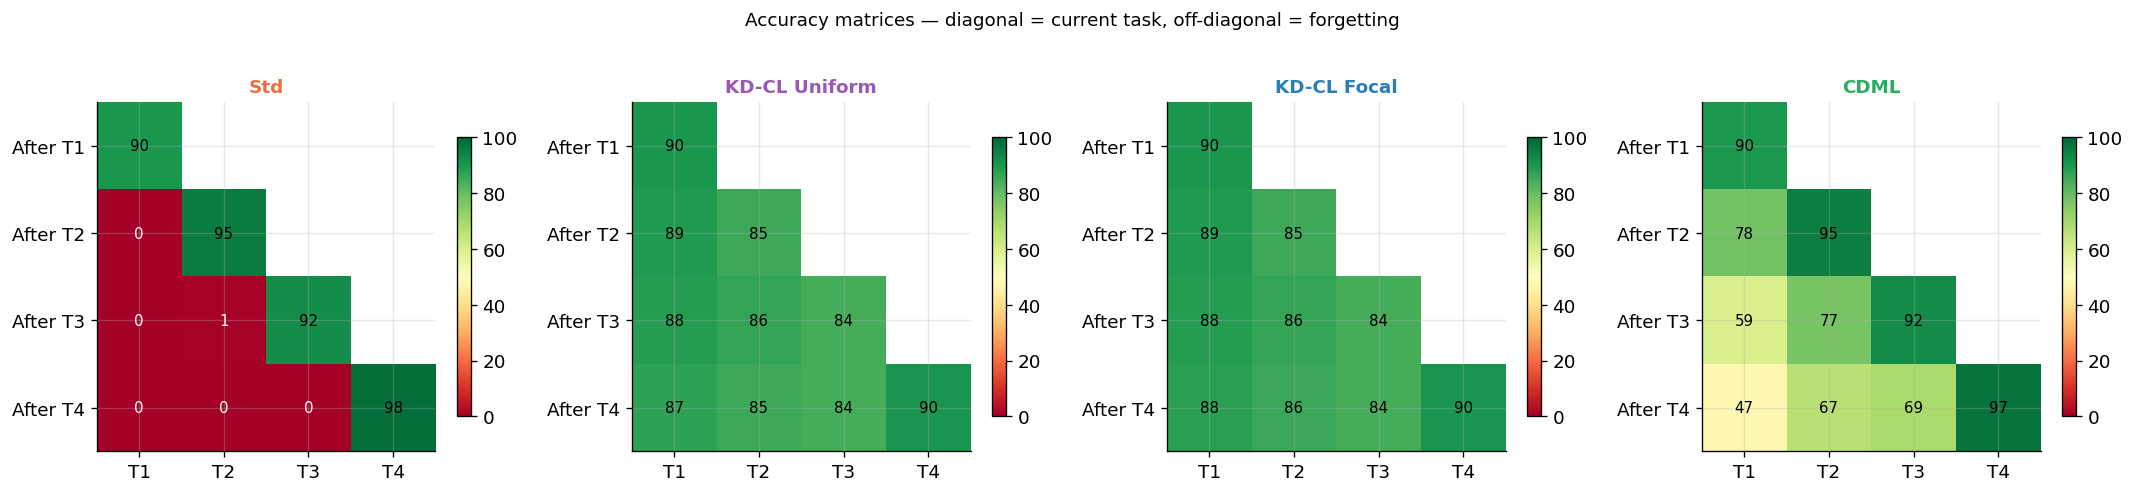

In [39]:
run_configs = [
    ('Std',             acc_std,        '#E87040'),
    ('KD-CL Uniform',   acc_kd_uniform, '#9B59B6'),
    ('KD-CL Focal',     acc_kd_focal,   '#2980B9'),
    ('CDML',            acc_cdml,       '#27AE60'),
]

# ── Accuracy matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (label, mat, color) in zip(axes, run_configs):
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(n_tasks))
    ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'After T{i+1}' for i in range(n_tasks)])
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i, j]):
                v = mat[i, j] * 100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=9, color='black' if v > 25 else 'white')

fig.suptitle('Accuracy matrices — diagonal = current task, off-diagonal = forgetting',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_kd_matrices.png', bbox_inches='tight')
plt.show()

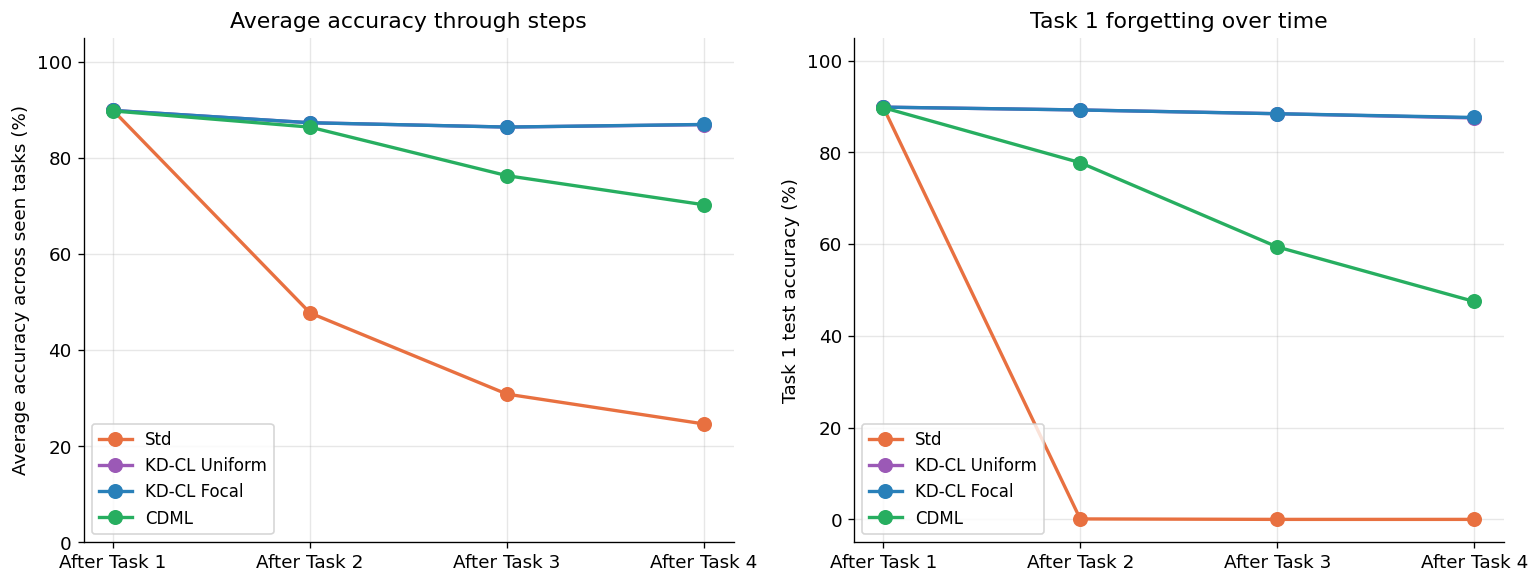

── Forgetting summary (initial acc on Task 1 → final acc) ──
  Std               : Task1 89.8% → 0.0%  (Δ = 89.8 pp)   Avg final = 24.6%
  KD-CL Uniform     : Task1 89.8% → 87.5%  (Δ = 2.4 pp)   Avg final = 86.9%
  KD-CL Focal       : Task1 89.8% → 87.6%  (Δ = 2.3 pp)   Avg final = 86.9%
  CDML              : Task1 89.7% → 47.5%  (Δ = 42.3 pp)   Avg final = 70.2%


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: average accuracy through steps ─────────────────────────────────────
ax = axes[0]
for label, mat, color in run_configs:
    avg = [np.nanmean(mat[step, :step+1]) * 100 for step in range(n_tasks)]
    ax.plot(range(1, n_tasks+1), avg, 'o-', color=color,
            linewidth=2, markersize=8, label=label)
ax.set_xticks(range(1, n_tasks+1))
ax.set_xticklabels([f'After Task {i}' for i in range(1, n_tasks+1)])
ax.set_ylabel('Average accuracy across seen tasks (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.set_title('Average accuracy through steps')

# ── Right: forgetting on Task 1 specifically ──────────────────────────────────
ax2 = axes[1]
for label, mat, color in run_configs:
    task1_accs = [mat[step, 0] * 100 for step in range(n_tasks)
                  if not np.isnan(mat[step, 0])]
    steps = list(range(1, len(task1_accs) + 1))
    ax2.plot(steps, task1_accs, 'o-', color=color,
             linewidth=2, markersize=8, label=label)
ax2.set_xticks(range(1, n_tasks+1))
ax2.set_xticklabels([f'After Task {i}' for i in range(1, n_tasks+1)])
ax2.set_ylabel('Task 1 test accuracy (%)')
ax2.set_ylim(-5, 105)
ax2.legend(fontsize=10)
ax2.set_title('Task 1 forgetting over time')

plt.tight_layout()
plt.savefig('fig_kd_forgetting.png', bbox_inches='tight')
plt.show()

# ── Numeric summary ───────────────────────────────────────────────────────────
print('── Forgetting summary (initial acc on Task 1 → final acc) ──')
for label, mat, _ in run_configs:
    init  = mat[0, 0] * 100
    final = mat[-1, 0] * 100
    avg_final = np.nanmean(mat[-1, :]) * 100
    print(f'  {label:<18}: Task1 {init:.1f}% → {final:.1f}%  '
          f'(Δ = {init-final:.1f} pp)   Avg final = {avg_final:.1f}%')

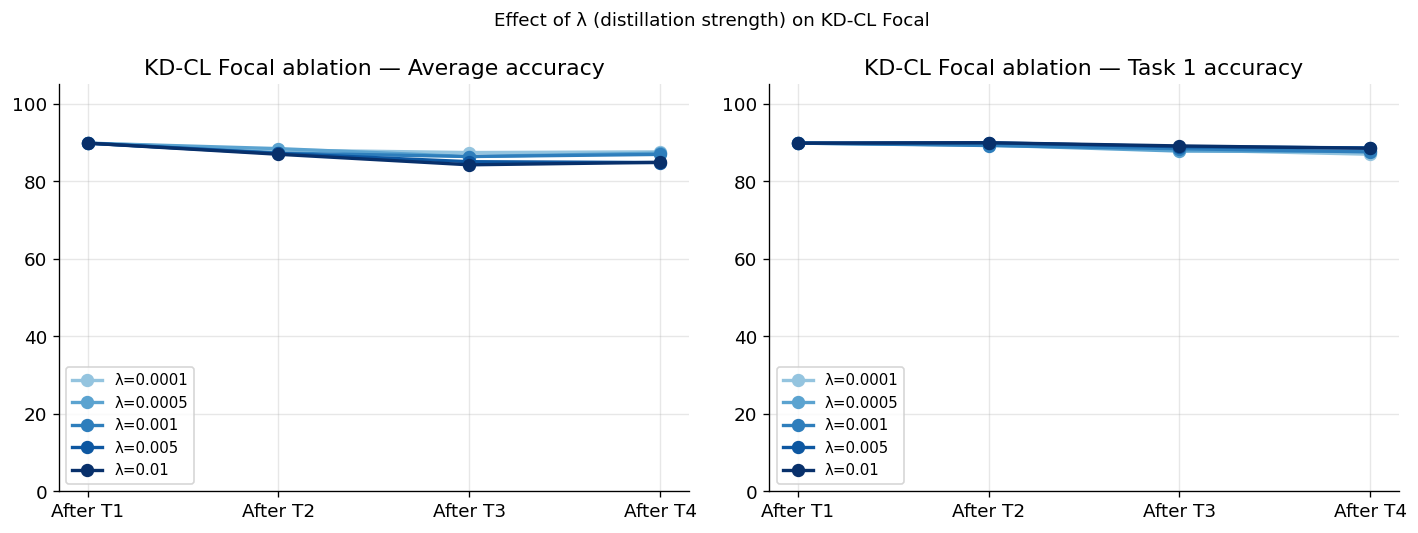

In [41]:
# ── λ ablation plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cmap = plt.cm.Blues(np.linspace(0.4, 1.0, len(lambda_values)))

for (lam, mat), color in zip(ablation_results.items(), cmap):
    avg = [np.nanmean(mat[step, :step+1]) * 100 for step in range(n_tasks)]
    axes[0].plot(range(1, n_tasks+1), avg, 'o-', color=color,
                 linewidth=2, markersize=7, label=f'λ={lam}')
    task1 = [mat[step, 0]*100 for step in range(n_tasks) if not np.isnan(mat[step,0])]
    axes[1].plot(range(1, len(task1)+1), task1, 'o-', color=color,
                 linewidth=2, markersize=7, label=f'λ={lam}')

for ax, title in zip(axes, ['Average accuracy', 'Task 1 accuracy']):
    ax.set_xticks(range(1, n_tasks+1))
    ax.set_xticklabels([f'After T{i}' for i in range(1, n_tasks+1)])
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.set_title(f'KD-CL Focal ablation — {title}')

plt.suptitle('Effect of λ (distillation strength) on KD-CL Focal', fontsize=11)
plt.tight_layout()
plt.savefig('fig_kd_lambda_ablation.png', bbox_inches='tight')
plt.show()

## 10. Save checkpoint

In [42]:
torch.save({
    'acc_std':        acc_std,
    'acc_kd_uniform': acc_kd_uniform,
    'acc_kd_focal':   acc_kd_focal,
    'acc_cdml':       acc_cdml,
    'ablation':       ablation_results,
    'config': {
        'epochs': EPOCHS, 'lr_init': LR_INIT, 'lr_decay': LR_DECAY,
        'lambda': LAMBDA, 'alpha': ALPHA, 'beta': BETA,
        'memory_fraction': MEMORY_FRACTION,
        'task_splits': TASK_SPLITS,
    },
}, 'checkpoint_phase5.pt')
print('Saved: checkpoint_phase5.pt')

Saved: checkpoint_phase5.pt


## 11. Discussion guide

### What to look for in the results

**Accuracy matrices.** Ideally KD-CL Focal and CDML both show less decay in the
off-diagonal cells compared to Std. If KD-CL outperforms Std but underperforms CDML,
that is already a meaningful result: it shows CDML achieves better forgetting mitigation
without any extra memory buffer.

**Uniform vs Focal.** The focal variant should outperform uniform because it
concentrates the distillation effort on samples the old model already knew. If they
perform similarly, it suggests the dataset does not have much intra-class variance
(which would make sense for gait, where all windows from one subject look similar).

**λ ablation.** There should be a clear sweet spot: too small and forgetting is not
prevented; too large and current-task accuracy suffers (the model is too anchored to
the old model to learn new subjects). This trade-off is a key contribution of your
thesis: quantifying it for gait IMU data.

### Key differences between KD-CL and CDML

| Aspect | KD-CL | CDML |
|---|---|---|
| **Mechanism** | Soft constraint in loss — anchors logit space | Feature scrambling — changes embedding geometry |
| **Memory needed** | Yes — buffer of ~20% past samples | No — only the 4-byte seed |
| **Privacy** | Past samples stored → more exposure | Seed only → minimal exposure |
| **Interpretability** | Clear: prevents logit drift | Less clear: why does scrambling help? |
| **Hyperparameters** | λ, α, β, memory fraction | Seed selection only |
| **Scalability** | Buffer grows with tasks | Fixed overhead |

### Possible further experiments

- [ ] Combine KD-CL + CDML: use the distillation loss *and* the modulating sequence
- [ ] Vary memory fraction (5%, 10%, 20%) — how little memory does KD-CL need?
- [ ] Use KL divergence instead of L2 for the distillation term
- [ ] Apply to Phase 4 MIA analysis: does KD-CL increase or decrease privacy vulnerability?

---
*Notebook: phase5_kd_vs_cdml.ipynb*